In [36]:
import awkward as ak
import matplotlib.pyplot as plt
import numpy as np
import uproot

fname = "../data/cms/phase2/offline/Aug31/ttbar_0pu/step3_inNANOAODSIM_13384142_1.root"
fh = uproot.open(fname)

print(fh.keys(recursive=False))

events = fh["Events"]
print(f"{events.num_entries} events, {len(events.keys())} branches")

['Events;1', 'LuminosityBlocks;1', 'Runs;1', 'MetaData;1', 'ParameterSets;1']
300 events, 484 branches


In [37]:
def doc(branch, *skip):
    """Branch title, i.e. the NanoAOD doc string. Empty if it just repeats the name."""
    title = branch.title.strip()
    return "" if title in skip or title == branch.name else title


keys = set(events.keys())

# a collection is a counter `n<Coll>` plus its `<Coll>_<field>` member branches
collections = {}
for k in keys:
    if k.startswith("n") and "_" not in k:
        members = sorted(m for m in keys if m.startswith(k[1:] + "_"))
        if members:
            collections[k[1:]] = members

print(f"{len(collections)} collections\n")
width = max(len(c) for c in collections)
for c in sorted(collections):
    d = doc(events["n" + c], c)
    print(f"{c:<{width}}  {len(collections[c]):3d} fields" + (f"   # {d}" if d else ""))

# everything else: event-level scalars, trigger bits, filter flags
grouped = {m for ms in collections.values() for m in ms} | {"n" + c for c in collections}
loose = sorted(keys - grouped)
print(f"\n{len(loose)} ungrouped branches (event-level / trigger / flags), e.g.:")
print("  ", [b for b in loose if not b.startswith(("HLT_", "Flag_"))])

58 collections

GSFTrack                                                    26 fields   # GSF tracks
GeneralTrack                                                29 fields   # General reconstructed tracks
HGCalGenPart                                                10 fields   # Gen particles for HGCAL studies
HGCalLayerClusters                                          11 fields   # Offline HGCAL Layer Clusters
RecoticlCandidate2SimCPByHits                                1 fields   # Association between ticlCandidate and SimTracksters, by hits.
RecoticlCandidate2SimCPByHitsLinks                           3 fields   # Association links.
RecoticlCandidate2SimSCByHits                                1 fields   # Association between ticlCandidate and SimTracksters, by hits.
RecoticlCandidate2SimSCByHitsLinks                           3 fields   # Association links.
RecoticlTracksterLinks2SimCPByHits                           1 fields   # Association between ticlTracksterLinks and SimTrackster

In [75]:
def print_fields(coll):
    """Print every field of a collection with its type and doc string."""
    members = sorted(k for k in events.keys() if k.startswith(coll + "_"))
    d = doc(events["n" + coll], coll)
    print(f"{coll}: {len(members)} fields" + (f"   # {d}" if d else ""))
    width = max(len(m) for m in members) - len(coll) - 1
    for m in members:
        b = events[m]
        print(f"  {m.split('_', 1)[1]:<{width}}  {b.typename:<11}  {b.title}")


print_fields("GSFTrack")

GSFTrack: 26 fields   # GSF tracks
  charge           int32_t[]    GSF track charge
  chargeMode       int32_t[]    GSF track charge Mode
  eta              float[]      GSF track pseudorapidity
  etaMode          float[]      GSF track Mode pseudorapidity
  etaModeError     float[]      GSF track Mode pseudorapidity Error
  lambdaMode       float[]      GSF track lambda Mode
  lambdaModeError  float[]      GSF track lambda Mode Error
  nhits            int32_t[]    GSF track nHits
  p                float[]      GSF track momentum magnitude [GeV]
  pMode            float[]      GSF track momentum Mode [GeV]
  phi              float[]      GSF track phi angle [rad]
  phiMode          float[]      GSF track phi angle Mode [rad]
  phiModeError     float[]      GSF track phi angle Mode Error
  pt               float[]      GSF track p_T [GeV]
  ptMode           float[]      GSF track p_T Mode [GeV]
  ptModeError      float[]      GSF track p_T Mode Error
  pxMode           float[]      GS

# LayerClusters
https://ticl.docs.cern.ch/concepts/layer-clusters/

In [76]:
print_fields("HGCalLayerClusters")

HGCalLayerClusters: 11 fields   # Offline HGCAL Layer Clusters
  algoID           int32_t[]    ID of the algo used for producing LayerCluster
  correctedEnergy  float[]      Corrected energy of the LayerCluster [GeV]
  energy           float[]      Energy of the LayerCluster [GeV]
  nHits            int32_t[]    Number of RecHits in LayerCluster
  position_eta     float[]      eta coordinate of the LayerCluster
  position_phi     float[]      phi coordinate of the LayerCluster
  position_x       float[]      X coordinate of the LayerCluster [cm]
  position_y       float[]      Y coordinate of the LayerCluster [cm]
  position_z       float[]      Z coordinate of the LayerCluster [cm]
  time             float[]      LayerCluster time [ns]
  timeError        float[]      LayerCluster timeError [ns]


In [97]:
"""
hgcal_em	        6	HGCAL CE-E (silicon, electromagnetic)
hgcal_had	        7	HGCAL CE-H silicon (hadronic)
hgcal_scintillator	8	HGCAL CE-H scintillator
hfnose	            9	HFNose
barrel_em	        10	ECAL barrel
barrel_had	        11	HCAL barrel
"""
events["HGCalLayerClusters_algoID"].arrays()[0]

<Record {HGCalLayerClusters_algoID: [...]} type='{HGCalLayerClusters_algoID...'>

In [ ]:
# Thousands of 2d layer clusters in a single ttbar_0pu event
len(ak.to_numpy(events["HGCalLayerClusters_energy"].array()[0]))

1381

In [100]:
algo = events["HGCalLayerClusters_algoID"].array()
flat = ak.to_numpy(ak.flatten(algo))

u, c = np.unique(flat, return_counts=True)
print("Layer clusters in Endcap:", dict(zip(u.tolist(), c.tolist())), f"  ({len(flat)} layer clusters)")

barrel = np.isin(flat, [10, 11])
print(f"Layer clusters in Barrel: {barrel.sum()} clusters = {100 * barrel.mean():.3f}%")

# per-event check, so you can see whether any single event has one
per_ev = ak.to_numpy(ak.sum((algo == 10) | (algo == 11), axis=1))
print(f"events containing any: {(per_ev > 0).sum()} / {len(per_ev)}")


Layer clusters in Endcap: {6: 1180200, 7: 132625, 8: 10663}   (1323488 layer clusters)
Layer clusters in Barrel: 0 clusters = 0.000%
events containing any: 0 / 300


In [105]:
a = events.arrays(["HGCalLayerClusters_position_eta", "HGCalLayerClusters_algoID"])
eta = ak.to_numpy(ak.flatten(a["HGCalLayerClusters_position_eta"]))
algo = ak.to_numpy(ak.flatten(a["HGCalLayerClusters_algoID"]))
abseta = np.abs(eta)

print(f"{len(eta)/events.num_entries:.0f} layer clusters per event on average\n")
print(f"  |eta| range: {abseta.min():.4f} .. {abseta.max():.4f}")
print(f"\n  |eta| < 1.5: {(abseta < 1.5).sum():6d}  ({100 * np.mean(abseta < 1.5):.3f}%)")
print(f"  |eta| > 3.0: {(abseta > 3.0).sum():6d}  ({100 * np.mean(abseta > 3.0):.3f}%)")

print("\n  by subdetector (algoID):")
for v, lab in [(6, "CE-E silicon"), (7, "CE-H silicon"), (8, "CE-H scintillator")]:
    m = algo == v
    if m.sum():
        x = abseta[m]
        print(f"    {v}  {lab:<18} n={m.sum():8d}   |eta| {x.min():.3f} .. {x.max():.3f}   median {np.median(x):.3f}")


4412 layer clusters per event on average

  |eta| range: 1.3379 .. 3.1365

  |eta| < 1.5:   3043  (0.230%)
  |eta| > 3.0:  50453  (3.812%)

  by subdetector (algoID):
    6  CE-E silicon       n= 1180200   |eta| 1.498 .. 3.124   median 2.271
    7  CE-H silicon       n=  132625   |eta| 1.496 .. 3.137   median 2.333
    8  CE-H scintillator  n=   10663   |eta| 1.338 .. 2.290   median 1.585


event 1: 12 tracksters, 116 SimTICLCandidates   [r<0.6, s<0.9]
  11 sim candidates matched, 0 tracksters with no surviving association
  fragmented (>1 trackster): 1 -> sim[39] pdg=130 x2


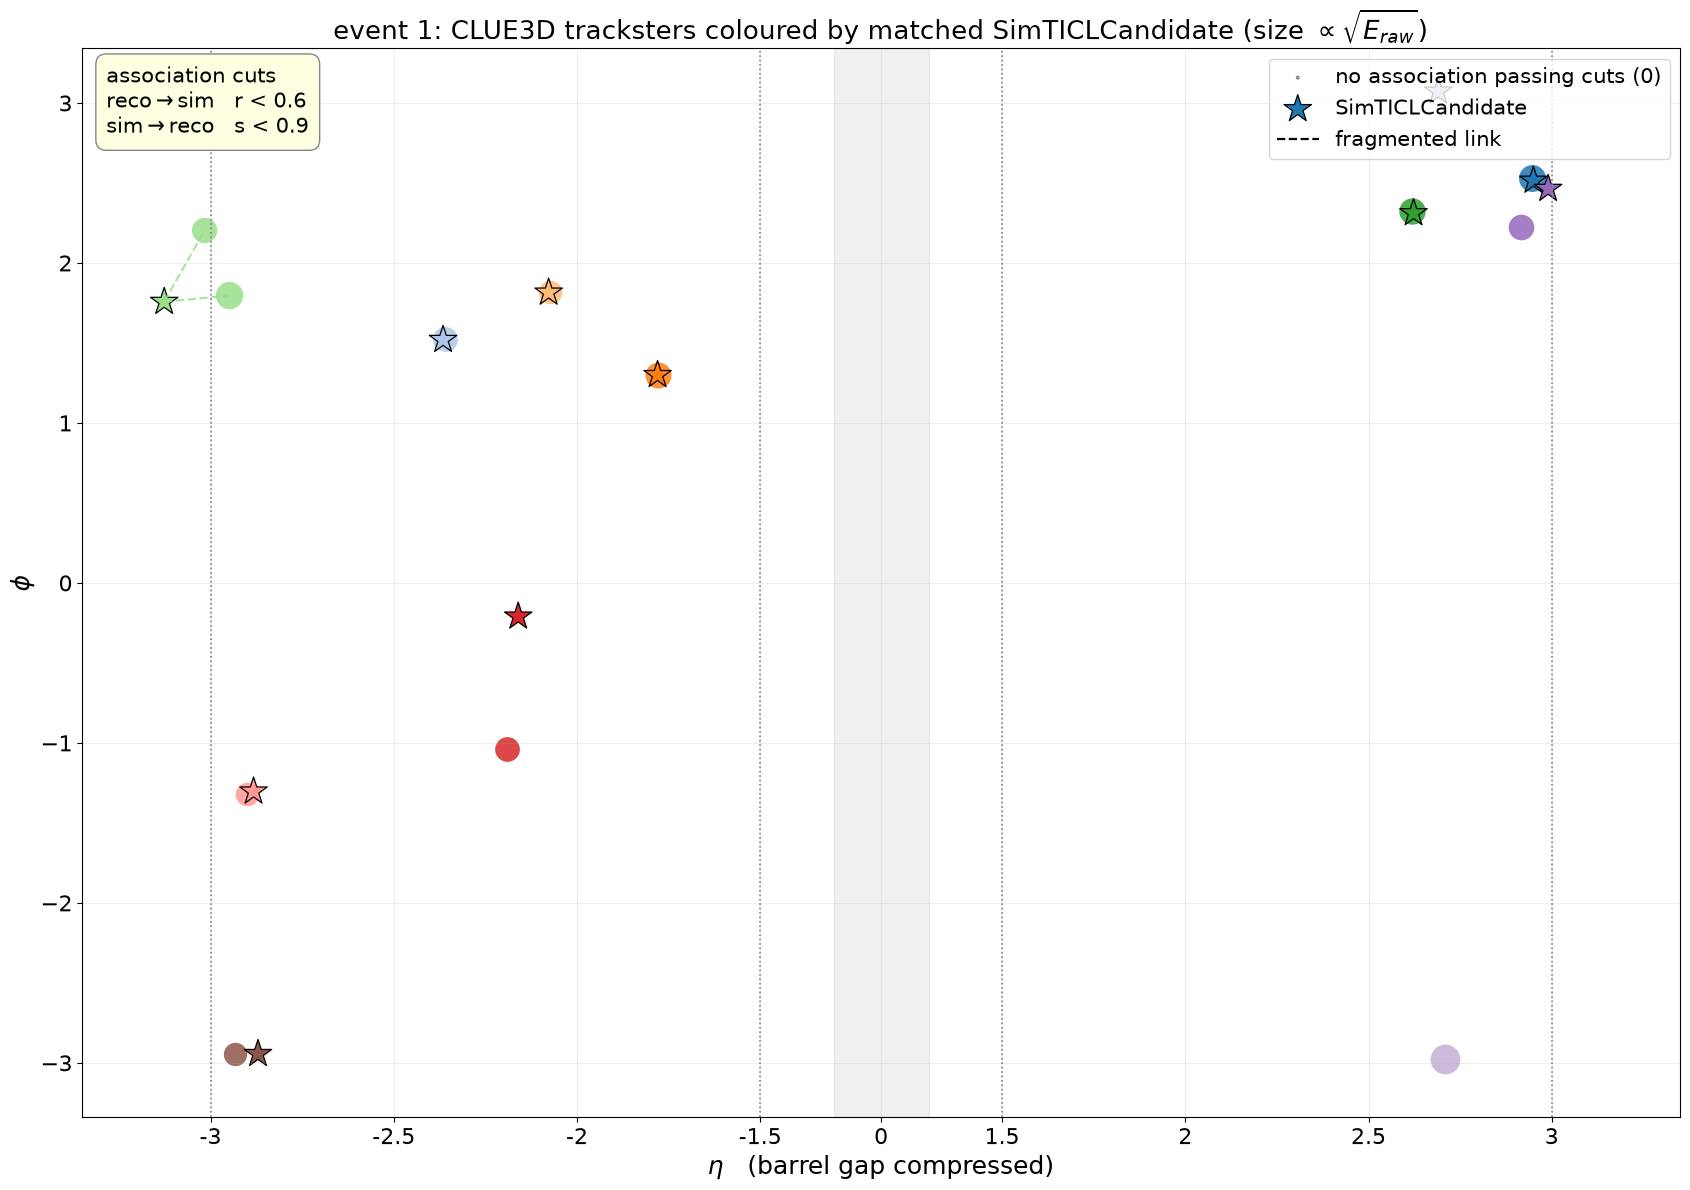

In [119]:
ev = 1
R_CUT = 0.6        # reco->sim score ("r"): keep link if r < R_CUT.  None = no cut
S_CUT = 0.9        # sim->reco score ("s"): keep link if s < S_CUT.  None = no cut
GAP, SQUEEZE = 1.3, 0.10   # compress the empty barrel region |eta| < GAP by this factor
FS = 15                    # base font size

R2S, S2R = "RecoticlTrackstersCLUE3DHigh2SimCPByHits", "SimCP2ticlTrackstersCLUE3DHighByHits"
T, S = "ticlTrackstersCLUE3DHigh", "SimTICLCandidates"

a = events.arrays(
    [f"{T}_barycenter_eta", f"{T}_barycenter_phi", f"{T}_raw_energy",
     f"{R2S}_n{R2S}Links", f"{R2S}Links_index", f"{R2S}Links_score",
     f"{S2R}_n{S2R}Links", f"{S2R}Links_index", f"{S2R}Links_score",
     f"{S}_eta", f"{S}_phi", f"{S}_pdgID"],
    entry_start=ev, entry_stop=ev + 1)

t_eta, t_phi = ak.to_numpy(a[f"{T}_barycenter_eta"][0]), ak.to_numpy(a[f"{T}_barycenter_phi"][0])
t_e = ak.to_numpy(a[f"{T}_raw_energy"][0])
s_eta, s_phi = ak.to_numpy(a[f"{S}_eta"][0]), ak.to_numpy(a[f"{S}_phi"][0])
s_pdg = ak.to_numpy(a[f"{S}_pdgID"][0])

s_lut, off = {}, 0
cs, isx, ss = (ak.to_numpy(a[f"{S2R}_n{S2R}Links"][0]),
               ak.to_numpy(a[f"{S2R}Links_index"][0]), ak.to_numpy(a[f"{S2R}Links_score"][0]))
for sim_i, n in enumerate(cs):
    for j in range(off, off + n):
        s_lut[(int(isx[j]), sim_i)] = ss[j]
    off += n

cr, ir, sr = (ak.to_numpy(a[f"{R2S}_n{R2S}Links"][0]),
              ak.to_numpy(a[f"{R2S}Links_index"][0]), ak.to_numpy(a[f"{R2S}Links_score"][0]))
best, off = np.full(len(t_eta), -1, int), 0
for i, n in enumerate(cr):
    cands = [(sr[j], int(ir[j])) for j in range(off, off + n)
             if (R_CUT is None or sr[j] < R_CUT)
             and (S_CUT is None or s_lut.get((i, int(ir[j])), np.inf) < S_CUT)]
    if cands:
        best[i] = min(cands)[1]
    off += n

# squeeze the empty |eta| < GAP band so the endcaps fill the frame
def sq(e):
    e = np.asarray(e, dtype=float)
    return np.where(np.abs(e) <= GAP, e * SQUEEZE,
                    np.sign(e) * (GAP * SQUEEZE + (np.abs(e) - GAP)))

matched = np.unique(best[best >= 0])
cmap = {s: plt.cm.tab20(k % 20) for k, s in enumerate(matched)}
frag = [s for s in matched if (best == s).sum() > 1]
print(f"event {ev}: {len(t_eta)} tracksters, {len(s_eta)} SimTICLCandidates   [r<{R_CUT}, s<{S_CUT}]")
print(f"  {len(matched)} sim candidates matched, {(best < 0).sum()} tracksters with no surviving association")
print(f"  fragmented (>1 trackster): {len(frag)} -> " +
      (", ".join(f"sim[{s}] pdg={s_pdg[s]} x{(best == s).sum()}" for s in frag[:6]) or "none"))

sz = lambda e: 40 + 420 * np.sqrt(e / t_e.max())
fig, ax = plt.subplots(figsize=(17, 12))

un = best < 0
ax.scatter(sq(t_eta[un]), t_phi[un], s=sz(t_e[un]), facecolor="none", edgecolor="grey", lw=1.8,
           label=f"no association passing cuts ({un.sum()})")
for s in matched:
    m = best == s
    ax.scatter(sq(t_eta[m]), t_phi[m], s=sz(t_e[m]), color=cmap[s], alpha=0.85, lw=0)
    if m.sum() > 1:
        for xx, yy in zip(sq(t_eta[m]), t_phi[m]):
            ax.plot([sq(s_eta[s]), xx], [s_phi[s], yy], color=cmap[s], lw=1.6, ls="--", alpha=0.8)
ax.scatter(sq(s_eta[matched]), s_phi[matched], marker="*", s=430,
           c=[cmap[s] for s in matched], edgecolor="k", lw=0.9, label="SimTICLCandidate")
ax.plot([], [], "k--", lw=1.6, label="fragmented link")

cut_txt = "\n".join([
    f"reco$\\to$sim   r < {R_CUT}" if R_CUT is not None else "reco$\\to$sim   (no cut)",
    f"sim$\\to$reco   s < {S_CUT}" if S_CUT is not None else "sim$\\to$reco   (no cut)"])
ax.text(0.015, 0.985, "association cuts\n" + cut_txt, transform=ax.transAxes, va="top", ha="left",
        fontsize=FS, bbox=dict(boxstyle="round,pad=0.5", fc="lightyellow", ec="grey", alpha=0.95))

ticks = np.array([-3.0, -2.5, -2.0, -1.5, 0.0, 1.5, 2.0, 2.5, 3.0])
ax.set_xticks(sq(ticks)); ax.set_xticklabels([f"{v:g}" for v in ticks])
ax.axvspan(sq(-GAP), sq(GAP), color="k", alpha=0.06)
for xv in (-3, -1.5, 1.5, 3):
    ax.axvline(sq(xv), color="grey", ls=":", lw=1.2)
ax.set_xlim(sq(-3.35), sq(3.35)); ax.set_ylim(-np.pi - 0.2, np.pi + 0.2)
ax.set_xlabel(r"$\eta$   (barrel gap compressed)", fontsize=FS + 3)
ax.set_ylabel(r"$\phi$", fontsize=FS + 3)
ax.tick_params(labelsize=FS + 1)
ax.grid(alpha=0.2)
ax.set_title(f"event {ev}: CLUE3D tracksters coloured by matched SimTICLCandidate "
             f"(size $\\propto \\sqrt{{E_{{raw}}}}$)", fontsize=FS + 4)
ax.legend(fontsize=FS, loc="upper right")
plt.tight_layout()
plt.show()


event 5: 7 fragmented particles  (r<0.6, s<0.9)
  sim[33] pdg=  130 E=  12.75 GeV -> 2 pieces, split [65.80000305175781, 34.20000076293945]%
  sim[35] pdg=  130 E=  21.93 GeV -> 3 pieces, split [51.20000076293945, 32.20000076293945, 16.600000381469727]%
  sim[74] pdg=  -13 E= 194.62 GeV -> 2 pieces, split [21.299999237060547, 78.69999694824219]%
  sim[81] pdg=  211 E=  33.56 GeV -> 2 pieces, split [50.20000076293945, 49.79999923706055]%
  sim[116] pdg=   22 E=   3.81 GeV -> 2 pieces, split [64.30000305175781, 35.70000076293945]%
  sim[119] pdg=   22 E=  10.34 GeV -> 2 pieces, split [41.79999923706055, 58.20000076293945]%
  sim[120] pdg=   22 E=  19.30 GeV -> 2 pieces, split [51.79999923706055, 48.20000076293945]%


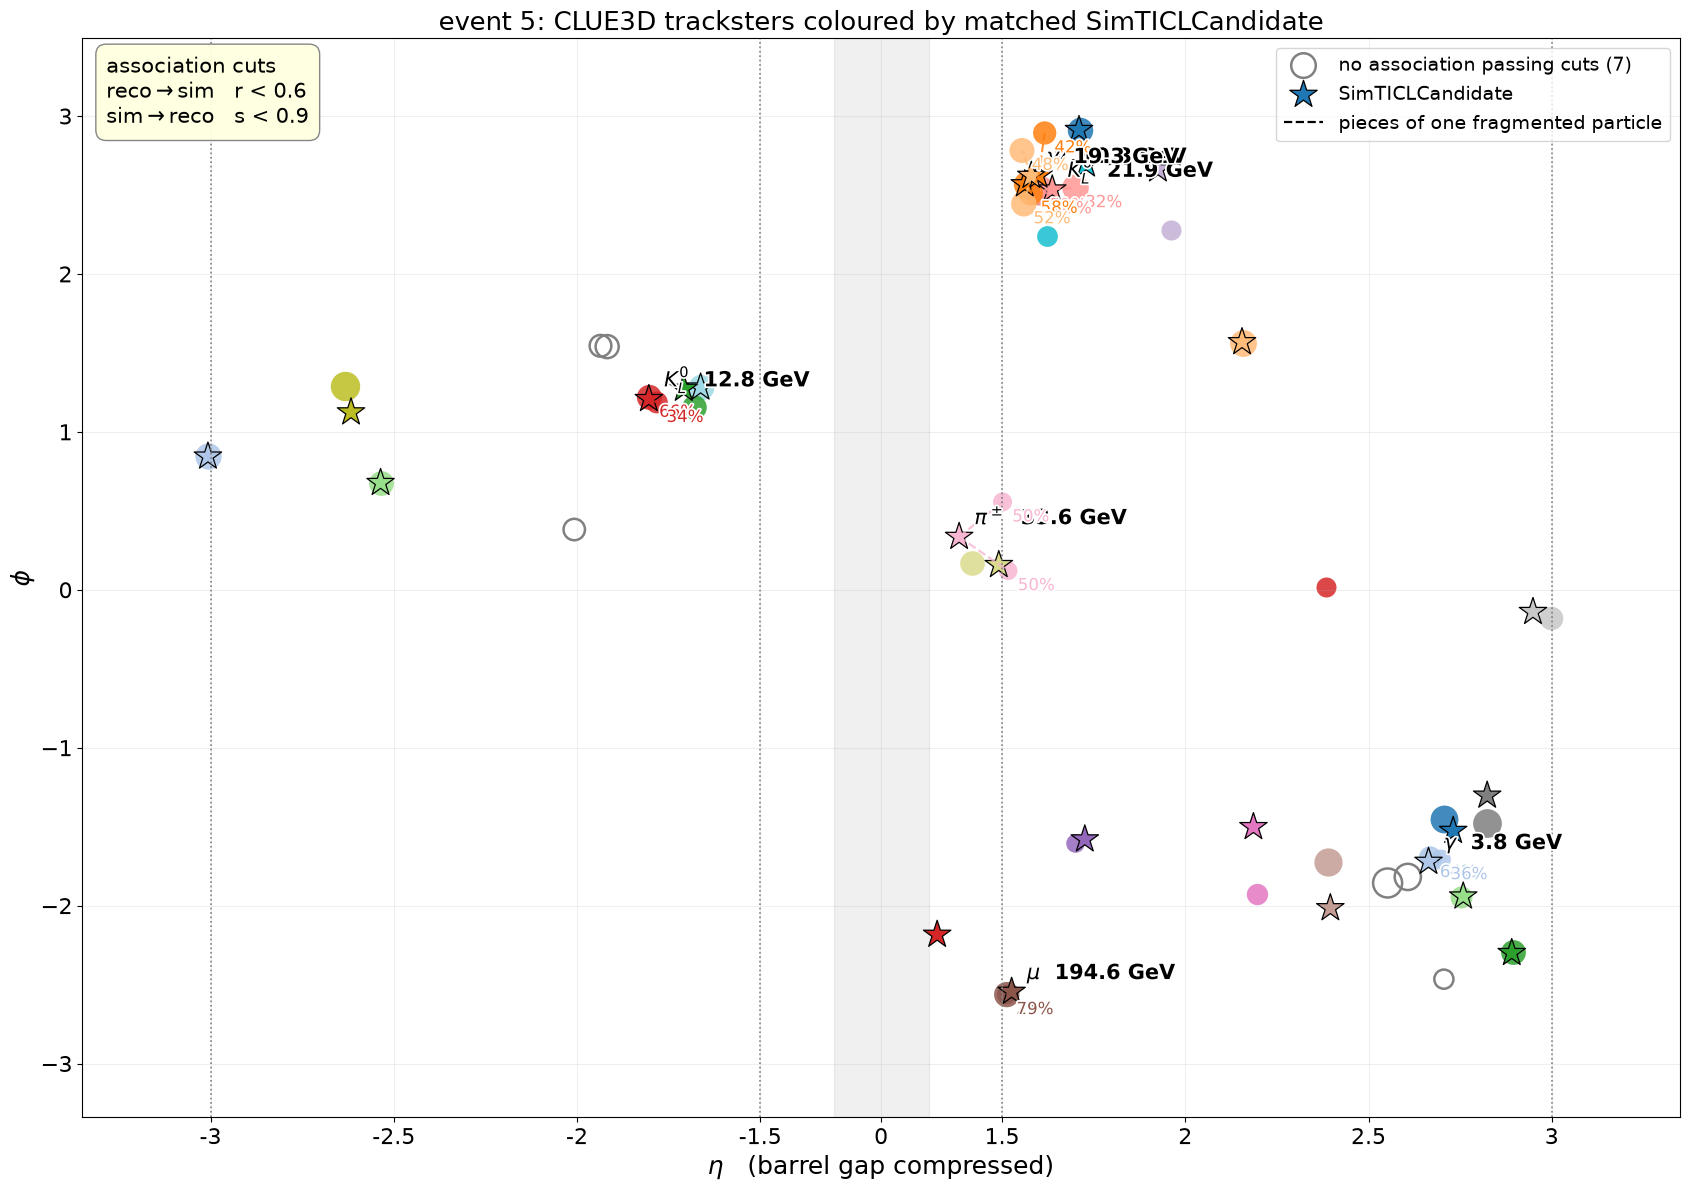

In [131]:
import matplotlib.patheffects as pe

ev = 5
R_CUT, S_CUT = 0.6, 0.9
# R_CUT, S_CUT = 1., 1.
GAP, SQUEEZE, FS = 1.3, 0.10, 15
MIN_FRAC_LABEL = 0.05          # only label pieces carrying >= this share

PID = {22: "$\\gamma$", 11: "$e$", 13: "$\\mu$", 211: "$\\pi^\\pm$", 130: "$K^0_L$"}
R2S, S2R = "RecoticlTrackstersCLUE3DHigh2SimCPByHits", "SimCP2ticlTrackstersCLUE3DHighByHits"
T, S = "ticlTrackstersCLUE3DHigh", "SimTICLCandidates"

a = events.arrays(
    [f"{T}_barycenter_eta", f"{T}_barycenter_phi", f"{T}_raw_energy",
     f"{R2S}_n{R2S}Links", f"{R2S}Links_index", f"{R2S}Links_score",
     f"{S2R}_n{S2R}Links", f"{S2R}Links_index", f"{S2R}Links_score", f"{S2R}Links_sharedEnergy",
     f"{S}_eta", f"{S}_phi", f"{S}_pdgID", f"{S}_energy"],
    entry_start=ev, entry_stop=ev + 1)
t_eta, t_phi = ak.to_numpy(a[f"{T}_barycenter_eta"][0]), ak.to_numpy(a[f"{T}_barycenter_phi"][0])
t_e = ak.to_numpy(a[f"{T}_raw_energy"][0])
s_eta, s_phi = ak.to_numpy(a[f"{S}_eta"][0]), ak.to_numpy(a[f"{S}_phi"][0])
s_pdg, s_en = ak.to_numpy(a[f"{S}_pdgID"][0]), ak.to_numpy(a[f"{S}_energy"][0])

# sim->reco score AND sharedEnergy, keyed by (trackster, simcand)
s_lut, sh_lut, off = {}, {}, 0
cs, isx, ss, shs = (ak.to_numpy(a[f"{S2R}_n{S2R}Links"][0]), ak.to_numpy(a[f"{S2R}Links_index"][0]),
                    ak.to_numpy(a[f"{S2R}Links_score"][0]), ak.to_numpy(a[f"{S2R}Links_sharedEnergy"][0]))
for sim_i, n in enumerate(cs):
    for j in range(off, off + n):
        s_lut[(int(isx[j]), sim_i)] = ss[j]
        sh_lut[(int(isx[j]), sim_i)] = shs[j]
    off += n

cr, ir, sr = (ak.to_numpy(a[f"{R2S}_n{R2S}Links"][0]),
              ak.to_numpy(a[f"{R2S}Links_index"][0]), ak.to_numpy(a[f"{R2S}Links_score"][0]))
best, off = np.full(len(t_eta), -1, int), 0
for i, n in enumerate(cr):
    c = [(sr[j], int(ir[j])) for j in range(off, off + n)
         if (R_CUT is None or sr[j] < R_CUT)
         and (S_CUT is None or s_lut.get((i, int(ir[j])), np.inf) < S_CUT)]
    if c:
        best[i] = min(c)[1]
    off += n

def sq(e):
    e = np.asarray(e, dtype=float)
    return np.where(np.abs(e) <= GAP, e * SQUEEZE, np.sign(e) * (GAP * SQUEEZE + (np.abs(e) - GAP)))

matched = np.unique(best[best >= 0])
cmap = {s: plt.cm.tab20(k % 20) for k, s in enumerate(matched)}
frag = [s for s in matched if (best == s).sum() > 1]

sz = lambda e: 40 + 420 * np.sqrt(e / t_e.max())
fig, ax = plt.subplots(figsize=(17, 12))
un = best < 0
ax.scatter(sq(t_eta[un]), t_phi[un], s=sz(t_e[un]), facecolor="none", edgecolor="grey", lw=1.8,
           label=f"no association passing cuts ({un.sum()})")
for s in matched:
    m = best == s
    ax.scatter(sq(t_eta[m]), t_phi[m], s=sz(t_e[m]), color=cmap[s], alpha=0.85, lw=0)
    if m.sum() > 1:
        for xx, yy in zip(sq(t_eta[m]), t_phi[m]):
            ax.plot([sq(s_eta[s]), xx], [s_phi[s], yy], color=cmap[s], lw=1.6, ls="--", alpha=0.8)
ax.scatter(sq(s_eta[matched]), s_phi[matched], marker="*", s=430,
           c=[cmap[s] for s in matched], edgecolor="k", lw=0.9, label="SimTICLCandidate")
ax.plot([], [], "k--", lw=1.6, label="pieces of one fragmented particle")

# annotate ONLY fragmented particles: PID + energy on the star, shared-E fraction on each piece
halo = [pe.withStroke(linewidth=2.5, foreground="w")]
print(f"event {ev}: {len(frag)} fragmented particles  (r<{R_CUT}, s<{S_CUT})")
for s in frag:
    pieces = np.where(best == s)[0]
    shared = np.array([sh_lut.get((int(i), int(s)), 0.0) for i in pieces])
    fr = shared / shared.sum() if shared.sum() > 0 else np.zeros_like(shared)
    sym = PID.get(abs(s_pdg[s]), str(s_pdg[s]))
    ax.annotate(f"{sym}  {s_en[s]:.1f} GeV", (sq(s_eta[s]), s_phi[s]), textcoords="offset points",
                xytext=(11, 9), fontsize=FS, fontweight="bold", zorder=7, path_effects=halo)
    for i, f in zip(pieces, fr):
        if f >= MIN_FRAC_LABEL:
            ax.annotate(f"{100 * f:.0f}%", (sq(t_eta[i]), t_phi[i]), textcoords="offset points",
                        xytext=(7, -14), fontsize=FS - 3, color=cmap[s], zorder=7, path_effects=halo)
    print(f"  sim[{s}] pdg={s_pdg[s]:5d} E={s_en[s]:7.2f} GeV -> {len(pieces)} pieces, "
          f"split {np.round(100 * fr, 1).tolist()}%")

ax.text(0.015, 0.985, f"association cuts\nreco$\\to$sim   r < {R_CUT}\nsim$\\to$reco   s < {S_CUT}",
        transform=ax.transAxes, va="top", ha="left", fontsize=FS,
        bbox=dict(boxstyle="round,pad=0.5", fc="lightyellow", ec="grey", alpha=0.95))
ticks = np.array([-3.0, -2.5, -2.0, -1.5, 0.0, 1.5, 2.0, 2.5, 3.0])
ax.set_xticks(sq(ticks)); ax.set_xticklabels([f"{v:g}" for v in ticks])
ax.axvspan(sq(-GAP), sq(GAP), color="k", alpha=0.06)
for xv in (-3, -1.5, 1.5, 3):
    ax.axvline(sq(xv), color="grey", ls=":", lw=1.2)
ax.set_xlim(sq(-3.35), sq(3.35)); ax.set_ylim(-np.pi - 0.2, np.pi + 0.35)
ax.set_xlabel(r"$\eta$   (barrel gap compressed)", fontsize=FS + 3)
ax.set_ylabel(r"$\phi$", fontsize=FS + 3)
ax.tick_params(labelsize=FS + 1); ax.grid(alpha=0.2)
ax.set_title(f"event {ev}: CLUE3D tracksters coloured by matched SimTICLCandidate", fontsize=FS + 4)
ax.legend(fontsize=FS - 1, loc="upper right")
plt.tight_layout()
plt.show()


In [133]:
import plotly.graph_objects as go

ev = 2
R_CUT, S_CUT = 0.6, 0.9
ZSIDE = +1              # +1, -1, or None for both endcaps
SHOW_LC = False         # True also draws each trackster's layer clusters as a faint cloud
OUT = "event3d.html"

PID = {22: "γ", 11: "e", 13: "μ", 211: "π±", 130: "K0L"}
R2S, S2R = "RecoticlTrackstersCLUE3DHigh2SimCPByHits", "SimCP2ticlTrackstersCLUE3DHighByHits"
T, S, SIM = "ticlTrackstersCLUE3DHigh", "SimTICLCandidates", "ticlSimTrackstersfromCPs"
LC, V = "HGCalLayerClusters", "ticlTrackstersCLUE3DHighvertices"

a = events.arrays(
    [f"{T}_barycenter_x", f"{T}_barycenter_y", f"{T}_barycenter_z", f"{T}_raw_energy", f"{T}_n{V}", f"{V}_vertices",
     f"{LC}_position_x", f"{LC}_position_y", f"{LC}_position_z", f"{LC}_energy",
     f"{SIM}_barycenter_x", f"{SIM}_barycenter_y", f"{SIM}_barycenter_z",
     f"{R2S}_n{R2S}Links", f"{R2S}Links_index", f"{R2S}Links_score",
     f"{S2R}_n{S2R}Links", f"{S2R}Links_index", f"{S2R}Links_score", f"{S2R}Links_sharedEnergy",
     f"{S}_pdgID", f"{S}_energy"],
    entry_start=ev, entry_stop=ev + 1)
g = lambda k: ak.to_numpy(a[k][0])
tx, ty, tz, t_e = g(f"{T}_barycenter_x"), g(f"{T}_barycenter_y"), g(f"{T}_barycenter_z"), g(f"{T}_raw_energy")
sx, sy, sz = g(f"{SIM}_barycenter_x"), g(f"{SIM}_barycenter_y"), g(f"{SIM}_barycenter_z")
s_pdg, s_en = g(f"{S}_pdgID"), g(f"{S}_energy")
nv, verts = g(f"{T}_n{V}"), g(f"{V}_vertices")
lx, ly, lz, le = g(f"{LC}_position_x"), g(f"{LC}_position_y"), g(f"{LC}_position_z"), g(f"{LC}_energy")

s_lut, sh_lut, off = {}, {}, 0
cs, isx, ss, shs = g(f"{S2R}_n{S2R}Links"), g(f"{S2R}Links_index"), g(f"{S2R}Links_score"), g(f"{S2R}Links_sharedEnergy")
for si, n in enumerate(cs):
    for j in range(off, off + n):
        s_lut[(int(isx[j]), si)] = ss[j]; sh_lut[(int(isx[j]), si)] = shs[j]
    off += n
cr, ir, sr = g(f"{R2S}_n{R2S}Links"), g(f"{R2S}Links_index"), g(f"{R2S}Links_score")
best, off = np.full(len(tx), -1, int), 0
for i, n in enumerate(cr):
    c = [(sr[j], int(ir[j])) for j in range(off, off + n)
         if (R_CUT is None or sr[j] < R_CUT) and (S_CUT is None or s_lut.get((i, int(ir[j])), np.inf) < S_CUT)]
    if c: best[i] = min(c)[1]
    off += n
lc_of = np.split(verts, np.cumsum(nv)[:-1])

keep = np.ones(len(tx), bool) if ZSIDE is None else (np.sign(tz) == ZSIDE)
matched = np.unique(best[(best >= 0) & keep])
PAL = ["#1f77b4","#ff7f0e","#2ca02c","#d62728","#9467bd","#8c564b","#e377c2","#bcbd22","#17becf",
       "#aec7e8","#ffbb78","#98df8a","#ff9896","#c5b0d5","#c49c94","#f7b6d2"]
col = {s: PAL[k % len(PAL)] for k, s in enumerate(matched)}
frag = [s for s in matched if ((best == s) & keep).sum() > 1]
sz_of = lambda e: 6 + 26 * np.sqrt(e / t_e[keep].max())

tr = []
un = np.where((best < 0) & keep)[0]
if len(un):
    tr.append(go.Scatter3d(x=tz[un], y=tx[un], z=ty[un], mode="markers", name=f"no association ({len(un)})",
        marker=dict(size=sz_of(t_e[un]), color="lightgrey", opacity=0.55, line=dict(width=1, color="grey")),
        text=[f"trackster {i}<br>E={t_e[i]:.2f} GeV" for i in un], hovertemplate="%{text}<extra></extra>"))

lbl_x, lbl_y, lbl_z, lbl_t = [], [], [], []
for s in matched:
    p = np.where((best == s) & keep)[0]
    sh = np.array([sh_lut.get((int(i), int(s)), 0.0) for i in p])
    fr = sh / sh.sum() if sh.sum() > 0 else np.zeros_like(sh)
    sym = PID.get(abs(s_pdg[s]), str(s_pdg[s]))
    tr.append(go.Scatter3d(x=tz[p], y=tx[p], z=ty[p], mode="markers", legendgroup=str(s),
        name=f"{sym} {s_en[s]:.0f}GeV [{s}] x{len(p)}",
        marker=dict(size=sz_of(t_e[p]), color=col[s], opacity=0.9, line=dict(width=1, color="black")),
        text=[f"trackster {i}<br>E={t_e[i]:.2f} GeV<br>share {100*f:.0f}%" for i, f in zip(p, fr)],
        hovertemplate="%{text}<extra></extra>"))
    tr.append(go.Scatter3d(x=[sz[s]], y=[sx[s]], z=[sy[s]], mode="markers", legendgroup=str(s), showlegend=False,
        marker=dict(size=13, color=col[s], symbol="diamond", line=dict(width=3, color="black")),
        text=[f"<b>SimTICLCandidate {s}</b><br>{sym}, E={s_en[s]:.1f} GeV<br>{len(p)} trackster(s)"],
        hovertemplate="%{text}<extra></extra>"))
    if len(p) > 1:                       # fragmented: link the pieces + label PID and shares
        X, Y, Z = [], [], []
        for i in p:
            X += [sz[s], tz[i], None]; Y += [sx[s], tx[i], None]; Z += [sy[s], ty[i], None]
        tr.append(go.Scatter3d(x=X, y=Y, z=Z, mode="lines", legendgroup=str(s), showlegend=False,
            line=dict(color=col[s], width=3, dash="dash"), hoverinfo="skip"))
        lbl_x.append(sz[s]); lbl_y.append(sx[s]); lbl_z.append(sy[s])
        lbl_t.append(f"<b>{sym} {s_en[s]:.0f} GeV</b>")
        for i, f in zip(p, fr):
            lbl_x.append(tz[i]); lbl_y.append(tx[i]); lbl_z.append(ty[i]); lbl_t.append(f"{100*f:.0f}%")
    if SHOW_LC:
        idx = np.concatenate([lc_of[i].astype(int) for i in p])
        tr.append(go.Scatter3d(x=lz[idx], y=lx[idx], z=ly[idx], mode="markers", legendgroup=str(s),
            showlegend=False, marker=dict(size=2.5, color=col[s], opacity=0.45), hoverinfo="skip"))
if lbl_t:
    tr.append(go.Scatter3d(x=lbl_x, y=lbl_y, z=lbl_z, mode="text", text=lbl_t, showlegend=False,
        textposition="top center", textfont=dict(size=13, color="black"), hoverinfo="skip"))

fig = go.Figure(tr)
fig.update_layout(height=880, template="plotly_white",
    title=f"event {ev}: tracksters + SimTICLCandidates (diamonds) — r&lt;{R_CUT}, s&lt;{S_CUT} — {len(frag)} fragmented",
    scene=dict(xaxis_title="z [cm]", yaxis_title="x [cm]", zaxis_title="y [cm]", aspectmode="data"),
    legend=dict(itemsizing="constant"))
fig.write_html(OUT, include_plotlyjs="cdn")
print(f"{len(matched)} matched, {len(frag)} fragmented, {len(un)} unassociated")
for s in frag:
    p = np.where((best == s) & keep)[0]
    sh = np.array([sh_lut.get((int(i), int(s)), 0.0) for i in p]); fr = sh / sh.sum()
    print(f"  [{s}] {PID.get(abs(s_pdg[s]), s_pdg[s])} E={s_en[s]:.1f} -> {np.round(100*fr).astype(int).tolist()}%")
fig.show()


20 matched, 4 fragmented, 22 unassociated
  [48] K0L E=154.0 -> [41, 59]%
  [127] K0L E=42.7 -> [81, 19]%
  [133] π± E=8.5 -> [49, 51]%
  [135] γ E=27.0 -> [42, 58]%


In [135]:
import webbrowser
from urllib.parse import urlencode

ART = "https://claude.ai/code/artifact/7a25057d-9b9c-4eb3-ab11-74089ffc23ea"

def show_event(ev=2, r=0.6, s=0.9, side=1, lc=False, only=False, unm=True, open_it=True):
    """Open the 3D viewer at a given event / cut setting. r or s = None disables that cut."""
    q = urlencode({"ev": ev, "r": 1.02 if r is None else r, "s": 1.02 if s is None else s,
                   "side": side, "lc": int(lc), "only": int(only), "unm": int(unm)})
    url = f"{ART}#{q}"
    if open_it:
        webbrowser.open(url)
    return url

show_event(ev=1, s=None, only=True)     # busiest event, s cut off, fragmented only


'https://claude.ai/code/artifact/7a25057d-9b9c-4eb3-ab11-74089ffc23ea#ev=1&r=0.6&s=1.02&side=1&lc=0&only=1&unm=1'

In [ ]:
# 

# One-one relationship between `Tracksters` and `SimTICLCandidate`

ticlTrackstersCLUE3DHigh   pt>0.5, |eta|>1.5, r<1.0, s<1.0
  24838 SimTICLCandidates pass the candidate-level cuts; 11960 keep >=1 trackster (48.2%)
    1 trackster      46.3%
    2 tracksters     17.9%
    >2 tracksters    35.8%


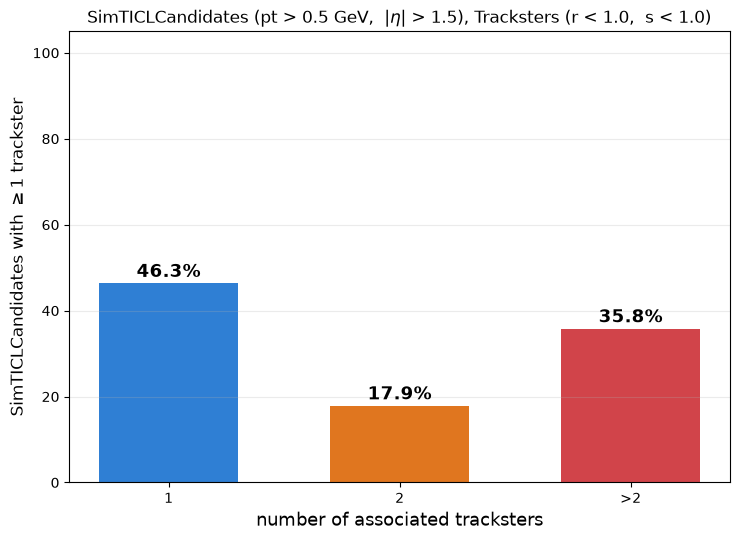

In [ ]:
PT_MIN   = 0.5      # SimTICLCandidate pt
ETA_MIN  = 1.5      # SimTICLCandidate |eta|
R_CUT    = 0.6      # per-link: drop a trackster whose reco->sim score >= this  (None = no cut)
S_CUT    = 0.9      # per-link: drop a trackster whose sim->reco score >= this  (None = no cut)
TS       = "ticlTrackstersCLUE3DHigh"

S2R = {"ticlTrackstersCLUE3DHigh": "SimCP2ticlTrackstersCLUE3DHighByHits",
       "ticlTracksterLinks": "SimCP2ticlTracksterLinksByHits"}[TS]
R2S = {"ticlTrackstersCLUE3DHigh": "RecoticlTrackstersCLUE3DHigh2SimCPByHits",
       "ticlTracksterLinks": "RecoticlTracksterLinks2SimCPByHits"}[TS]

def regroup(flat, counts):
    inner = ak.to_numpy(ak.flatten(counts)).astype(np.int64)
    outer = ak.to_numpy(ak.num(counts, axis=1)).astype(np.int64)
    return ak.unflatten(ak.unflatten(ak.flatten(flat), inner), outer)

cs  = events[f"{S2R}_n{S2R}Links"].array()
idx = regroup(events[f"{S2R}Links_index"].array(), cs)
s2r = regroup(events[f"{S2R}Links_score"].array(), cs)
shr = regroup(events[f"{S2R}Links_sharedEnergy"].array(), cs)
cr  = events[f"{R2S}_n{R2S}Links"].array()
rsc = regroup(events[f"{R2S}Links_score"].array(), cr)
eta, pt = events["SimTICLCandidates_eta"].array(), events["SimTICLCandidates_pt"].array()
RE = events["SimTICLCandidates_raw_energy"].array()          # <-- E no longer needed

n_kept = []
for ev in range(events.num_entries):
    rbest = {ti: (min(ss) if len(ss) else 2.0) for ti, ss in enumerate(rsc[ev].tolist())}
    for si, (js, sc, sh) in enumerate(zip(idx[ev].tolist(), s2r[ev].tolist(), shr[ev].tolist())):
        # ---- candidate-level cuts ----
        if abs(float(eta[ev][si])) < ETA_MIN or float(pt[ev][si]) < PT_MIN:
            continue
        # ---- per-link cuts ----
        k = sum(1 for j, s, e in zip(js, sc, sh)
                if e > 0
                and (S_CUT is None or s < S_CUT)
                and (R_CUT is None or rbest.get(int(j), 2.0) < R_CUT))
        n_kept.append(k)
n_kept = np.array(n_kept)

linked = n_kept[n_kept > 0]
frac = np.array([np.mean(linked == 1), np.mean(linked == 2), np.mean(linked > 2)]) * 100

print(f"{TS}   pt>{PT_MIN}, |eta|>{ETA_MIN}, r<{R_CUT}, s<{S_CUT}")
print(f"  {len(n_kept)} SimTICLCandidates pass the candidate-level cuts; "
      f"{len(linked)} keep >=1 trackster ({100*len(linked)/len(n_kept):.1f}%)")
for lab, v in zip(["1 trackster", "2 tracksters", ">2 tracksters"], frac):
    print(f"    {lab:<15} {v:5.1f}%")

fig, ax = plt.subplots(figsize=(7.5, 5.5))
bars = ax.bar(["1", "2", ">2"], frac, color=["#2f7fd4", "#e0761f", "#d1444a"], width=.6)
for b, v in zip(bars, frac):
    ax.text(b.get_x() + b.get_width()/2, v + 1.5, f"{v:.1f}%", ha="center", fontsize=13, fontweight="bold")
ax.set_ylim(0, 105); ax.grid(axis="y", alpha=.25)
ax.set_xlabel("number of associated tracksters", fontsize=13)
ax.set_ylabel("SimTICLCandidates with $\\geq$1 trackster", fontsize=12)
ax.set_title(f"SimTICLCandidates (pt > {PT_MIN} GeV,  |$\\eta$| > {ETA_MIN}), Tracksters (r < {R_CUT},  s < {S_CUT})", fontsize=12)
plt.tight_layout(); plt.show()


SimTICLCandidates passing candidate cuts: 8611
  with 0 tracksters: 2694  (31.3%)

  charged (associated with a track)     1821    67.6%   median raw_E  8.17 GeV   median raw/truth 0.859
  charged (NOT associated with a track)   291    10.8%   median raw_E  7.56 GeV   median raw/truth 0.394
  neutral                                582    21.6%   median raw_E  8.37 GeV   median raw/truth 0.774


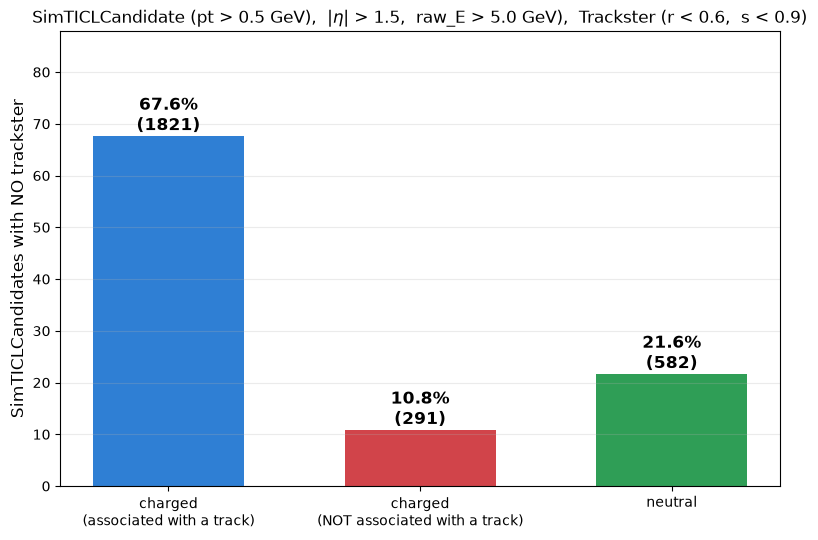

In [195]:
PT_MIN, ETA_MIN = 0.5, 1.5
RAWE_MIN = 5.0     # SimTICLCandidate raw_energy in GeV -- absolute deposit (None = no cut)
R_CUT, S_CUT = 0.6, 0.9
# R_CUT, S_CUT = 1., 1.
TS = "ticlTrackstersCLUE3DHigh"
S2R = {"ticlTrackstersCLUE3DHigh": "SimCP2ticlTrackstersCLUE3DHighByHits",
       "ticlTracksterLinks": "SimCP2ticlTracksterLinksByHits"}[TS]
R2S = {"ticlTrackstersCLUE3DHigh": "RecoticlTrackstersCLUE3DHigh2SimCPByHits",
       "ticlTracksterLinks": "RecoticlTracksterLinks2SimCPByHits"}[TS]

def regroup(flat, counts):
    inner = ak.to_numpy(ak.flatten(counts)).astype(np.int64)
    outer = ak.to_numpy(ak.num(counts, axis=1)).astype(np.int64)
    return ak.unflatten(ak.unflatten(ak.flatten(flat), inner), outer)

cs = events[f"{S2R}_n{S2R}Links"].array()
idx = regroup(events[f"{S2R}Links_index"].array(), cs)
s2r = regroup(events[f"{S2R}Links_score"].array(), cs)
shr = regroup(events[f"{S2R}Links_sharedEnergy"].array(), cs)
cr  = events[f"{R2S}_n{R2S}Links"].array()
rsc = regroup(events[f"{R2S}Links_score"].array(), cr)
eta, pt = events["SimTICLCandidates_eta"].array(), events["SimTICLCandidates_pt"].array()
chg, trk = events["SimTICLCandidates_charge"].array(), events["SimTICLCandidates_trackIdx"].array()
pdg = events["SimTICLCandidates_pdgID"].array()
E, RE = events["SimTICLCandidates_energy"].array(), events["SimTICLCandidates_raw_energy"].array()
INT_NULL = np.iinfo(np.int32).min

n_kept, is_chg, has_trk, P, RR, DEP = [], [], [], [], [], []
for ev in range(events.num_entries):
    rbest = {ti: (min(ss) if len(ss) else 2.0) for ti, ss in enumerate(rsc[ev].tolist())}
    for si, (js, sc, sh) in enumerate(zip(idx[ev].tolist(), s2r[ev].tolist(), shr[ev].tolist())):
        # ---- candidate-level cuts ----
        if abs(float(eta[ev][si])) < ETA_MIN or float(pt[ev][si]) < PT_MIN:
            continue
        re_ = float(RE[ev][si])                                     # <-- changed
        if RAWE_MIN is not None and re_ < RAWE_MIN:                 # <-- changed
            continue
        # ---- per-link cuts ----
        k = sum(1 for j, s, e in zip(js, sc, sh)
                if e > 0 and (S_CUT is None or s < S_CUT)
                and (R_CUT is None or rbest.get(int(j), 2.0) < R_CUT))
        n_kept.append(k); is_chg.append(int(chg[ev][si]) != 0)
        has_trk.append(int(trk[ev][si]) != INT_NULL); P.append(abs(int(pdg[ev][si])))
        RR.append(re_); DEP.append(re_ / float(E[ev][si]))          # <-- changed
n_kept, is_chg, has_trk = np.array(n_kept), np.array(is_chg), np.array(has_trk)
P, RR, DEP = np.array(P), np.array(RR), np.array(DEP)

zero = n_kept == 0
CHARGED_PDG = np.isin(P, [211, 321, 11, 13, 2212])
groups = [("charged\n(associated with a track)", zero & is_chg),
          ("charged\n(NOT associated with a track)", zero & ~is_chg & CHARGED_PDG),
          ("neutral", zero & ~is_chg & ~CHARGED_PDG)]

rawe = "off" if RAWE_MIN is None else f"{RAWE_MIN} GeV"
print(f"SimTICLCandidates passing candidate cuts: {len(n_kept)}")
print(f"  with 0 tracksters: {zero.sum()}  ({100*zero.mean():.1f}%)\n")
for lab, m in groups:
    print(f"  {lab.replace(chr(10),' '):<36} {m.sum():5d}   {100*m.sum()/max(zero.sum(),1):5.1f}%   "
          f"median raw_E {np.median(RR[m]) if m.sum() else 0:5.2f} GeV   "
          f"median raw/truth {np.median(DEP[m]) if m.sum() else 0:.3f}")

frac = [100*m.sum()/zero.sum() for _, m in groups]
fig, ax = plt.subplots(figsize=(8, 5.5))
bars = ax.bar([g[0] for g in groups], frac, color=["#2f7fd4", "#d1444a", "#2f9e56"], width=.6)
for b, v, (_, m) in zip(bars, frac, groups):
    ax.text(b.get_x() + b.get_width()/2, v + 1.2, f"{v:.1f}%\n({m.sum()})",
            ha="center", fontsize=12, fontweight="bold")
ax.set_ylim(0, max(frac) * 1.30); ax.grid(axis="y", alpha=.25)
ax.set_ylabel("SimTICLCandidates with NO trackster", fontsize=12)
ax.set_title(f"SimTICLCandidate (pt > {PT_MIN} GeV),  |$\\eta$| > {ETA_MIN},  raw_E > {rawe}),  Trackster (r < {R_CUT},  s < {S_CUT})", fontsize=12)
plt.tight_layout(); plt.show()


charged WITH a track: n=12336
   primary (matches a status-1 GenParticle) :  76.5%
   secondary (no gen match)                 :  23.5%
   never crossed the HGCAL front face       :  16.2%
   shower start: median layer 4, median |z| 322 cm
   median raw_energy 3.49 GeV
charged with NO track: n=1864
   primary (matches a status-1 GenParticle) :   1.6%
   secondary (no gen match)                 :  98.4%
   never crossed the HGCAL front face       :  94.3%
   shower start: median layer 1, median |z| 322 cm
   median raw_energy 2.19 GeV


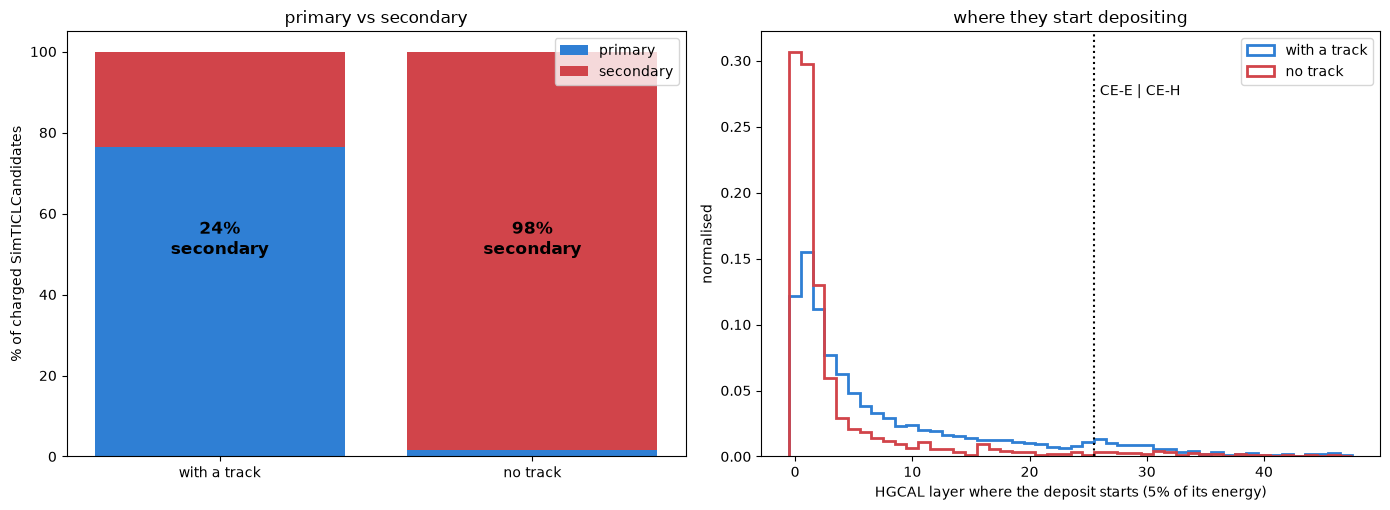

In [196]:
PT_MIN, ETA_MIN, NEV = 0.5, 1.5, 300
DR_GEN = 0.05
SIM = "ticlSimTrackstersfromCPs"

def regroup(flat, counts):
    inner = ak.to_numpy(ak.flatten(counts)).astype(np.int64)
    outer = ak.to_numpy(ak.num(counts, axis=1)).astype(np.int64)
    return ak.unflatten(ak.unflatten(ak.flatten(flat), inner), outer)

csim = events[f"{SIM}_n{SIM}vertices"].array(entry_stop=NEV)
sv = regroup(events[f"{SIM}vertices_vertices"].array(entry_stop=NEV), csim)
bz = events[f"{SIM}_boundaryZ"].array(entry_stop=NEV)
lcZ = events["HGCalLayerClusters_position_z"].array(entry_stop=NEV)
lcE = events["HGCalLayerClusters_energy"].array(entry_stop=NEV)
sc = events.arrays([f"SimTICLCandidates_{k}" for k in
                    ("eta","phi","pt","pdgID","charge","energy","raw_energy")], entry_stop=NEV)
gp = events.arrays([f"HGCalGenPart_{k}" for k in ("eta","phi","pdgId","status")], entry_stop=NEV)
PLANES = np.unique(np.round(np.abs(ak.to_numpy(ak.flatten(lcZ))), 0))

rows = []
for ev in range(NEV):
    Z, E = np.abs(ak.to_numpy(lcZ[ev])), ak.to_numpy(lcE[ev])
    ge, gph = ak.to_numpy(gp["HGCalGenPart_eta"][ev]), ak.to_numpy(gp["HGCalGenPart_phi"][ev])
    gid, gst = ak.to_numpy(gp["HGCalGenPart_pdgId"][ev]), ak.to_numpy(gp["HGCalGenPart_status"][ev])
    st1 = gst == 1
    se, sp = ak.to_numpy(sc["SimTICLCandidates_eta"][ev]), ak.to_numpy(sc["SimTICLCandidates_phi"][ev])
    spt, spd = ak.to_numpy(sc["SimTICLCandidates_pt"][ev]), ak.to_numpy(sc["SimTICLCandidates_pdgID"][ev])
    sch, sre = ak.to_numpy(sc["SimTICLCandidates_charge"][ev]), ak.to_numpy(sc["SimTICLCandidates_raw_energy"][ev])
    bzz = ak.to_numpy(bz[ev])
    for si in range(len(se)):
        if abs(se[si]) < ETA_MIN or spt[si] < PT_MIN: continue
        if abs(spd[si]) not in (211, 321, 11, 13, 2212): continue
        d = np.hypot(ge[st1]-se[si], (gph[st1]-sp[si]+np.pi) % (2*np.pi) - np.pi)
        same = np.abs(gid[st1]) == abs(spd[si])
        is_primary = bool((d[same] < DR_GEN).any()) if same.any() else False
        vi = np.asarray(sv[ev][si], dtype=int)
        if len(vi):                     # shower start = shallowest layer holding 5% of its deposit
            lay = np.searchsorted(PLANES, np.round(Z[vi], 0)); e = E[vi]
            o = np.argsort(lay); cum = np.cumsum(e[o]) / max(e.sum(), 1e-9)
            start, zstart = int(lay[o][np.searchsorted(cum, 0.05)]), float(Z[vi].min())
        else:
            start, zstart = -1, -1.0
        rows.append((sch[si] != 0, is_primary, start, zstart, float(bzz[si]) == 0.0, float(sre[si])))
trk = np.array([r[0] for r in rows]); prim = np.array([r[1] for r in rows])
start = np.array([r[2] for r in rows]); zs = np.array([r[3] for r in rows])
nob = np.array([r[4] for r in rows]); raw = np.array([r[5] for r in rows])

for lab, m in [("charged WITH a track", trk), ("charged with NO track", ~trk)]:
    g = m & (start >= 0)
    print(f"{lab}: n={m.sum()}")
    print(f"   primary (matches a status-1 GenParticle) : {100*np.mean(prim[m]):5.1f}%")
    print(f"   secondary (no gen match)                 : {100*np.mean(~prim[m]):5.1f}%")
    print(f"   never crossed the HGCAL front face       : {100*np.mean(nob[m]):5.1f}%")
    print(f"   shower start: median layer {np.median(start[g]):.0f}, median |z| {np.median(zs[g]):.0f} cm")
    print(f"   median raw_energy {np.median(raw[m]):.2f} GeV")

fig, axs = plt.subplots(1, 2, figsize=(14, 5.2))
axs[0].bar(["with a track", "no track"], [100*np.mean(prim[trk]), 100*np.mean(prim[~trk])],
           color="#2f7fd4", label="primary")
axs[0].bar(["with a track", "no track"], [100*np.mean(~prim[trk]), 100*np.mean(~prim[~trk])],
           bottom=[100*np.mean(prim[trk]), 100*np.mean(prim[~trk])], color="#d1444a", label="secondary")
for i, m in enumerate([trk, ~trk]):
    axs[0].text(i, 50, f"{100*np.mean(~prim[m]):.0f}%\nsecondary", ha="center", fontsize=12, fontweight="bold")
axs[0].set_ylabel("% of charged SimTICLCandidates"); axs[0].legend(fontsize=10)
axs[0].set_title("primary vs secondary")

b = np.arange(-0.5, 48.5)
for lab, m, c in [("with a track", trk & (start >= 0), "#2f7fd4"), ("no track", ~trk & (start >= 0), "#d1444a")]:
    axs[1].hist(start[m], bins=b, density=True, histtype="step", lw=2, color=c, label=lab)
axs[1].axvline(25.5, color="k", ls=":"); axs[1].text(26, axs[1].get_ylim()[1]*.85, "CE-E | CE-H", fontsize=10)
axs[1].set_xlabel("HGCAL layer where the deposit starts (5% of its energy)")
axs[1].set_ylabel("normalised"); axs[1].legend(fontsize=10); axs[1].set_title("where they start depositing")
plt.tight_layout(); plt.show()
